# Лабораторная работа №1 — HGBat

**Дисциплина:** «Эволюционное программирование и генетические алгоритмы».  
**Вариант 20:** $d=7$, $x_i\in[-15,15]$. Задача — минимизация.

Ноутбук использует реализацию из `src` и результаты полных экспериментов.
Для повторения экспериментов выполните `python -m src.experiments` из `project-1`.
Для демонстрации достаточно **Run All**: повторный поиск здесь не запускается.

## Функция и теоретический ориентир

$$f(x)=\sqrt{\left|\left(\sum_{i=1}^d x_i^2\right)^2-\left(\sum_{i=1}^d x_i\right)^2\right|}+\frac{0.5\sum_{i=1}^d x_i^2+\sum_{i=1}^d x_i}{d}+0.5.$$

Последние два слагаемых равны $\frac{1}{2d}\sum_i(x_i+1)^2\ge0$.
При $x^*=(-1,\ldots,-1)$ оба неотрицательных слагаемых равны нулю.
Таким образом, глобальный минимум равен нулю. **Координаты оптимума используются
только для проверки и анализа, а не внутри поиска.**

In [1]:
from pathlib import Path
import json
import sys
import numpy as np
import pandas as pd
from IPython.display import Image, Markdown, display

cwd = Path.cwd().resolve()
candidates = [cwd, *cwd.parents]
candidates += [path / "project-1" for path in list(candidates)]
ROOT = next((path for path in candidates
             if (path / "src/objective.py").is_file()
             and (path / "config/default.json").is_file()), None)
if ROOT is None:
    raise FileNotFoundError("Откройте ноутбук из репозитория или папки project-1")
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
from src.objective import hgbat, is_feasible
from src.experiments import load_config, experiment_configs

config, number_of_runs = load_config(ROOT / "config/default.json")
print("Папка проекта:", ROOT.name)
print("HGBat в теоретическом оптимуме:", hgbat(np.full(config.dimension, -1.0)))

Папка проекта: project-1
HGBat в теоретическом оптимуме: 0.0


## Методика

Сравниваются GA Config A (σ = 1.5), GA Config B (σ = 3.0) и Random Search.
Все используют seed 0–19 и по 50 000 оценок на запуск. A и B отличаются только σ.
Турнир из 3 особей, арифметический кроссовер с вероятностью 0.9,
покоординатная гауссовская мутация с вероятностью 1/7, clipping и одна элитная особь.
Ниже проверяются именно параметры сохранённого эксперимента.

In [2]:
summary_dir = ROOT / "results/summary"
if not (summary_dir / "statistics.csv").exists():
    raise FileNotFoundError("Сначала выполните python -m src.experiments из project-1")
metadata = json.loads((summary_dir / "experiment_metadata.json").read_text(encoding="utf-8"))
display(pd.DataFrame(metadata["configurations"]))
assert metadata["seeds"] == list(range(20)), "Для сдачи нужны 20 запусков"
assert all(c["evaluation_budget"] == 50000 for c in metadata["configurations"].values())
assert all(c["dimension"] == 7 and c["lower_bound"] == -15 and c["upper_bound"] == 15
           for c in metadata["configurations"].values())
a, b = [metadata["configurations"][name] for name in ("ga_config_a", "ga_config_b")]
assert [key for key in a if a[key] != b[key]] == ["mutation_sigma"]
print("Оценок целевой функции:", metadata["total_objective_evaluations"])
print("Версии библиотек:", metadata["packages"])

,ga_config_a,ga_config_b,random_search
dimension,7.000000,7.000000,7.000000
lower_bound,-15.000000,-15.000000,-15.000000
upper_bound,15.000000,15.000000,15.000000
population_size,100.000000,100.000000,100.000000
tournament_size,3.000000,3.000000,3.000000
crossover_probability,0.900000,0.900000,0.900000
mutation_probability,0.142857,0.142857,0.142857
mutation_sigma,1.500000,3.000000,3.000000
elite_count,1.000000,1.000000,1.000000
evaluation_budget,50000.000000,50000.000000,50000.000000


Оценок целевой функции: 3000000
Версии библиотек: {'numpy': '2.5.3', 'pandas': '3.0.6', 'matplotlib': '3.11.2'}


## Итоговая статистика

Меньшее значение лучше. `std` — выборочное стандартное отклонение (`ddof=1`).
Среднее описывает общий уровень, медиана менее чувствительна к крайним значениям,
разброс показывает зависимость результата от seed.

In [3]:
statistics = pd.read_csv(summary_dir / "statistics.csv")
display(statistics.round(8))
results = {method: pd.read_csv(ROOT / "results/raw" / f"{method}.csv")
           for method in metadata["configurations"]}
for method, frame in results.items():
    assert frame["seed"].tolist() == metadata["seeds"]
    assert (frame["evaluations"] == 50000).all()
    display(Markdown(f"**{method}: первые пять запусков**"))
    display(frame.head())

,method,best,mean,median,std,worst,runs,std_ddof
0,ga_config_a,0.240224,0.316383,0.320344,0.043220,0.383305,20,1
1,ga_config_b,0.108752,0.277797,0.278665,0.055900,0.361154,20,1
2,random_search,13.096084,27.723106,27.380590,8.248822,40.317267,20,1


**ga_config_a: первые пять запусков**

,seed,best_fitness,evaluations,generations,x1,x2,x3,x4,x5,x6,x7
0,0,0.330954,50000,505,-1.259833,-1.192193,-0.593558,0.045110,-0.379794,-0.093836,-0.044761
1,1,0.252809,50000,505,-0.031134,0.282948,-0.934149,-0.619517,-1.160666,-0.254365,-0.966408
2,2,0.382777,50000,505,-0.127380,-1.314467,0.019777,-0.670447,0.065833,0.024867,-0.270918
3,3,0.361411,50000,505,-0.996404,-0.200361,-0.270894,-0.476111,0.424981,0.125522,-0.837307
4,4,0.339601,50000,505,0.073772,-0.340713,-1.136763,-1.174806,-0.168956,0.045730,-0.143841


**ga_config_b: первые пять запусков**

,seed,best_fitness,evaluations,generations,x1,x2,x3,x4,x5,x6,x7
0,0,0.361154,50000,505,-0.880749,-1.141737,0.338426,-1.180403,-0.630691,-0.612564,-0.539287
1,1,0.271502,50000,505,-0.530889,0.114431,-0.324707,-1.444418,-0.350683,-0.583820,-1.147196
2,2,0.299329,50000,505,-0.353354,-1.682092,-0.495084,-0.352458,-0.020435,-0.376207,-0.247652
3,3,0.322956,50000,505,-0.189369,-0.186564,-1.001040,-0.422181,0.114080,-1.374511,-0.104166
4,4,0.242801,50000,505,-0.457998,-1.184479,0.076967,-0.120489,-1.375851,-0.610889,-0.347416


**random_search: первые пять запусков**

,seed,best_fitness,evaluations,x1,x2,x3,x4,x5,x6,x7
0,0,39.070986,50000,1.088940,-0.691059,-1.245435,-3.604657,-0.365109,-3.681614,2.702052
1,1,22.962229,50000,-2.371825,-1.452222,-2.382418,0.974726,-0.981619,0.467249,2.468295
2,2,31.552302,50000,-1.482458,1.190223,3.293851,2.137672,-1.971145,0.199082,2.408417
3,3,13.096084,50000,2.761094,1.022389,-0.543596,0.184715,1.632190,-0.561483,0.016215
4,4,35.150463,50000,-1.798387,3.992045,-2.147119,2.362487,-1.654091,-0.450114,0.003303


## Сходимость

Линии показывают среднее лучшее найденное значение, полупрозрачная область —
минимум и максимум по seed. Справа увеличен участок после первых 20 поколений.
Поколение 0 соответствует начальной популяции; последний шаг может быть неполным.
Слева шкала symlog позволяет видеть начало поиска и малые итоговые значения; справа линейная шкала подробно показывает поздние поколения.
Сужение области означает уменьшение разброса между запусками.

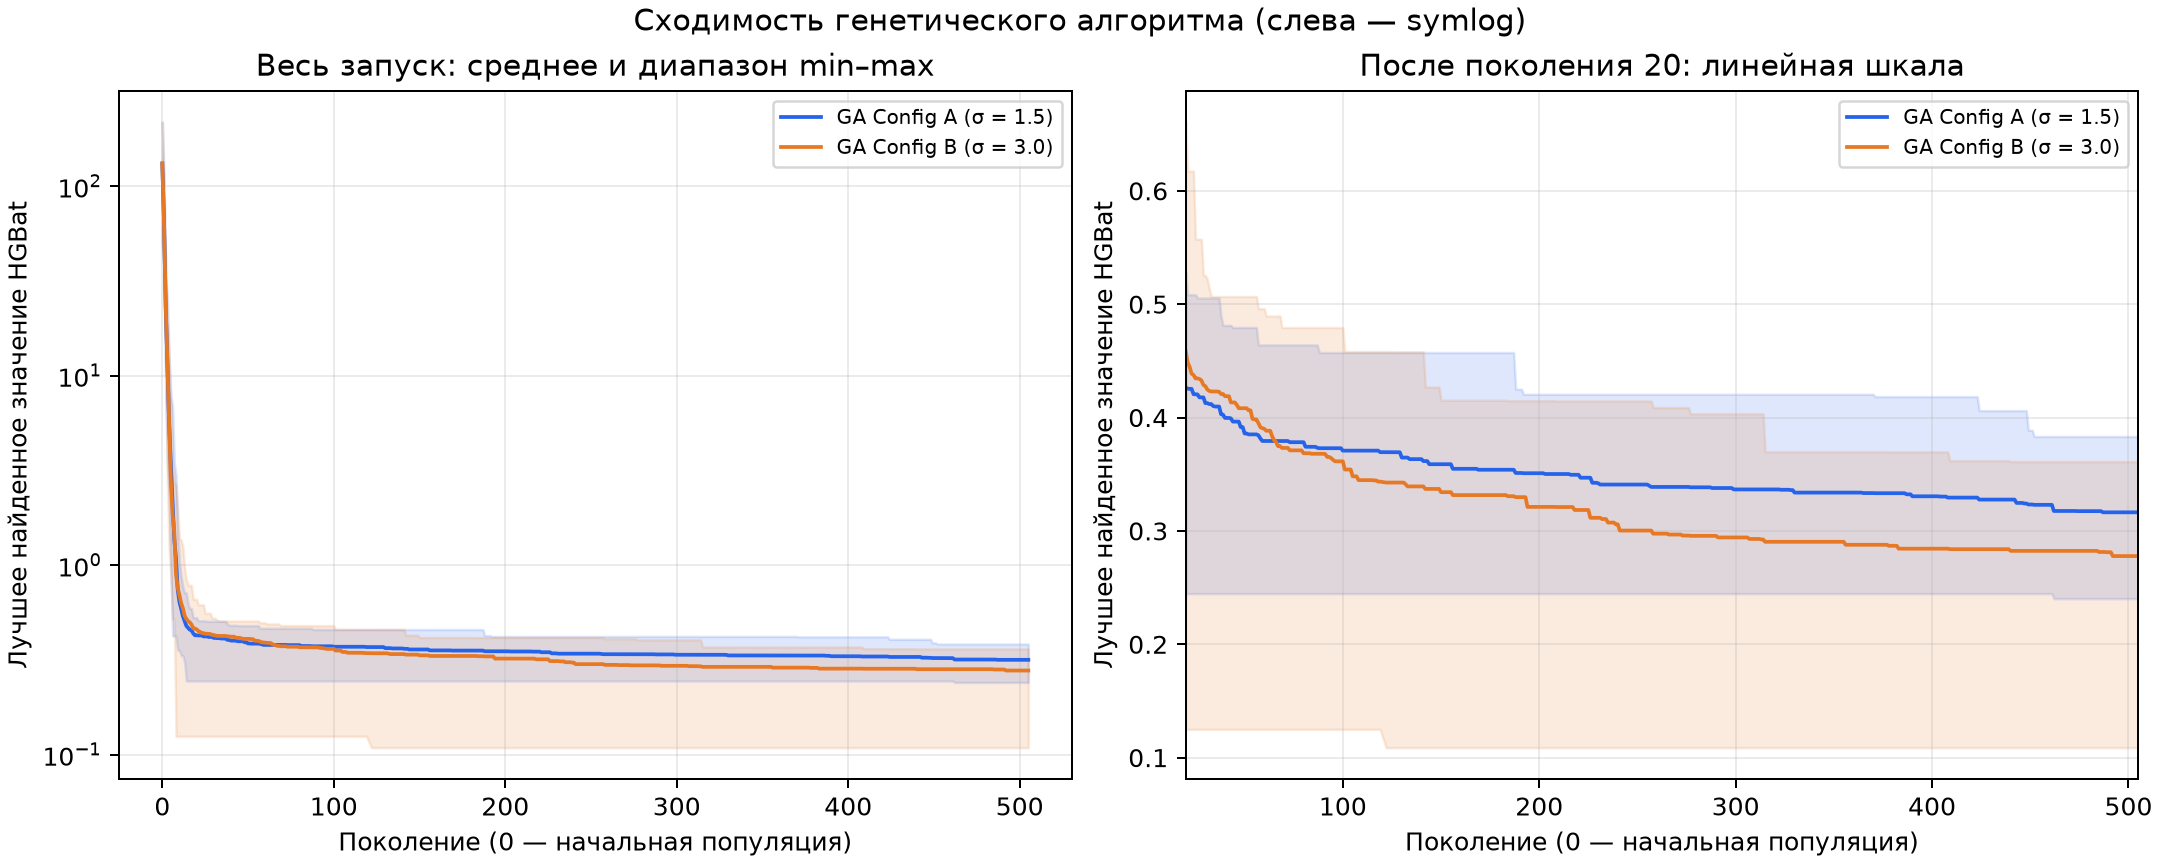

In [4]:
histories = {method: pd.read_csv(ROOT / "results/raw" / f"convergence_{method}.csv")
             for method in ("ga_config_a", "ga_config_b")}
for method, history in histories.items():
    assert (history["population_size"] == 100).all()
    assert (history.groupby("seed")["evaluation_count"].max() == 50000).all()
    for _, run in history.groupby("seed"):
        assert np.all(np.diff(run["global_best_fitness"]) <= 0)
display(Image(filename=str(ROOT / "figures/convergence.png")))

## Сравнение методов

Каждая точка — один запуск. Линия внутри коробки — медиана, коробка —
межквартильный диапазон, усы ограничиваются 1.5 межквартильного размаха.
Все значения, включая выбросы, показаны отдельными точками.
Сравнение проводится по одинаковому числу оценок функции, не по времени выполнения.

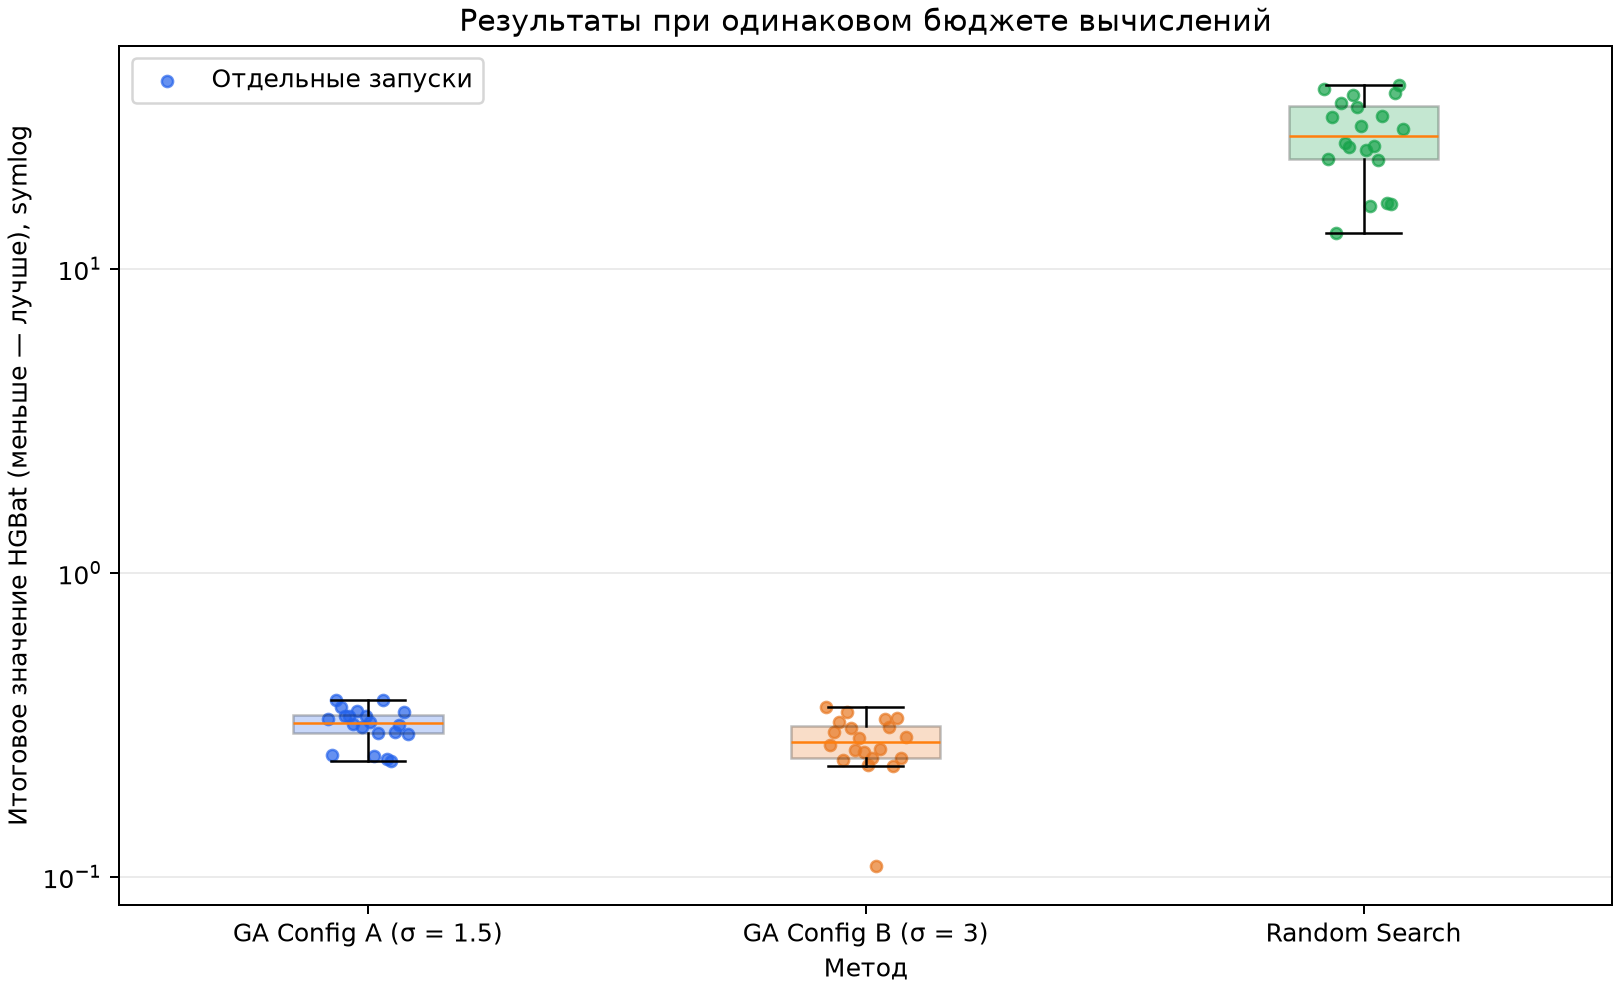

В этой серии меньшее среднее у **ga_config_b**: **0.27779741**. Среднее Random Search: **27.72310635**. Это эмпирическое сравнение, без утверждения о статистической значимости.

In [5]:
display(Image(filename=str(ROOT / "figures/final_comparison.png")))
means = statistics.set_index("method")["mean"]
better_ga = means[["ga_config_a", "ga_config_b"]].idxmin()
display(Markdown(f"В этой серии меньшее среднее у **{better_ga}**: "
                 f"**{means[better_ga]:.8f}**. Среднее Random Search: "
                 f"**{means['random_search']:.8f}**. "
                 "Это эмпирическое сравнение, без утверждения о статистической значимости."))

## Лучшие векторы и расстояние до оптимума

Расстояние $\|x-x^*\|_2$ — дополнительная диагностика, не критерий селекции.
Показаны лучшие запуски каждого метода; выбирать метод только по одному удачному
запуску некорректно, поэтому выше приведена статистика всех повторов.

In [6]:
coordinates = [f"x{i}" for i in range(1, config.dimension + 1)]
optimum = np.full(config.dimension, -1.0)
best_rows = []
for method, frame in results.items():
    row = frame.loc[frame["best_fitness"].idxmin()]
    vector = row[coordinates].to_numpy(dtype=float)
    assert is_feasible(vector)
    assert np.isclose(hgbat(vector), row["best_fitness"], atol=1e-10)
    best_rows.append({"method": method, "seed": int(row["seed"]),
                      "best_fitness": row["best_fitness"],
                      "distance_to_optimum": np.linalg.norm(vector - optimum),
                      **dict(zip(coordinates, vector))})
best = pd.DataFrame(best_rows)
display(best)
winner = best.loc[best["best_fitness"].idxmin()]
vector = winner[coordinates].to_numpy(dtype=float)
print("Лучший метод:", winner["method"], "seed:", int(winner["seed"]))
print("Лучший вектор:", np.array2string(vector, precision=10))
print("Теоретический оптимум:", optimum)
print("f(x) =", hgbat(vector))
print("Расстояние до оптимума =", np.linalg.norm(vector - optimum))

,method,seed,best_fitness,distance_to_optimum,x1,x2,x3,x4,x5,x6,x7
0,ga_config_a,15,0.240224,1.672301,-1.021386,-0.616859,-1.259797,-0.190181,-1.053815,0.118174,-0.179740
1,ga_config_b,12,0.108752,1.146661,-0.562980,-0.611355,-0.916448,-0.331276,-1.199772,-0.543461,-1.519895
2,random_search,3,13.096084,5.291612,2.761094,1.022389,-0.543596,0.184715,1.632190,-0.561483,0.016215


Лучший метод: ga_config_b seed: 12
Лучший вектор: [-0.5629802083 -0.6113554848 -0.9164478511 -0.3312755155 -1.1997723413
 -0.543461049  -1.5198950187]
Теоретический оптимум: [-1. -1. -1. -1. -1. -1. -1.]
f(x) = 0.1087520337201277
Расстояние до оптимума = 1.1466611913391669


## Выводы и ограничения

По результатам 20 запусков Config B имеет меньшее среднее (0.27779741 против 0.31638255) и медиану, но больший std (0.05590044 против 0.04321959). Config B лучше Config A в 14 из 20 пар seed. Оба варианта ГА дают меньшие значения, чем Random Search (среднее 27.72310635).

Лучшее полученное значение 0.10875203 остаётся выше теоретического нуля. Элитизм сохраняет рекорд, но не гарантирует нахождение глобального минимума. Результаты относятся к одной функции, размерности и бюджету; тест статистической значимости не проводился. Полный разбор находится в `report.md`.